In [1]:
import cv2
import matplotlib.pyplot as plt

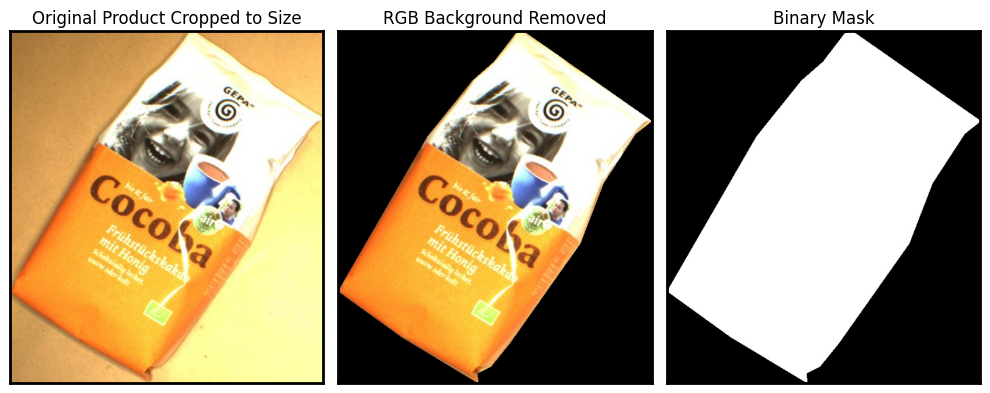

In [2]:
normal_img = cv2.imread("printout/binary/coco_normal.jpg", cv2.COLOR_BGR2RGB)
normal_img = cv2.cvtColor(normal_img, cv2.COLOR_BGR2RGB)

bg_img = cv2.imread("printout/binary//coco_bg.jpg", cv2.COLOR_BGR2RGB)
bg_img = cv2.cvtColor(bg_img, cv2.COLOR_BGR2RGB)

mask_img = cv2.imread("printout/binary//coco_binary.jpg", cv2.IMREAD_GRAYSCALE)

fig, axs = plt.subplots(1, 3, figsize=(10,5))
axs[0].set_title("Original Product Cropped to Size")
axs[0].imshow(normal_img)
axs[1].set_title("RGB Background Removed")
axs[1].imshow(bg_img)
axs[2].set_title("Binary Mask")
axs[2].imshow(mask_img, cmap="gray")
for ax in axs:
    ax.set_yticks([])
    ax.set_xticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_color('black')
fig.tight_layout()
plt.show()


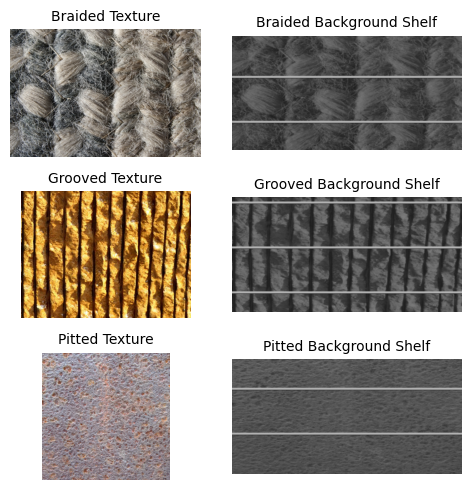

In [3]:
braided_img = cv2.imread("printout/shelf_simulator/braided_0007.jpg", cv2.COLOR_BGR2RGB)
braided_img_shelf = cv2.imread("printout/shelf_simulator/braided_0007_shelf.jpg", cv2.COLOR_BGR2RGB)

braided_img = cv2.cvtColor(braided_img, cv2.COLOR_BGR2RGB)
braided_img_shelf = cv2.cvtColor(braided_img_shelf, cv2.COLOR_BGR2RGB)

grooved_img = cv2.imread("printout/shelf_simulator/grooved_0141.jpg", cv2.COLOR_BGR2RGB)
grooved_img_shelf = cv2.imread("printout/shelf_simulator/grooved_0141_shelf.jpg", cv2.COLOR_BGR2RGB)

grooved_img = cv2.cvtColor(grooved_img, cv2.COLOR_BGR2RGB)
grooved_img_shelf = cv2.cvtColor(grooved_img_shelf, cv2.COLOR_BGR2RGB)

pitted_img = cv2.imread("printout/shelf_simulator/pitted_0082.jpg", cv2.COLOR_BGR2RGB)
pitted_img_shelf = cv2.imread("printout/shelf_simulator/pitted_0082_shelf.jpg", cv2.COLOR_BGR2RGB)

pitted_img = cv2.cvtColor(pitted_img, cv2.COLOR_BGR2RGB)
pitted_img_shelf = cv2.cvtColor(pitted_img_shelf, cv2.COLOR_BGR2RGB)


fig, axs = plt.subplots(3, 2, figsize=(5,5), gridspec_kw={'width_ratios':[2,2]})
axs[0, 0].set_title("Braided Texture", fontsize=10)
axs[0, 0].imshow(braided_img)
axs[0, 1].set_title("Braided Background Shelf", fontsize=10)
axs[0, 1].imshow(braided_img_shelf)

axs[1, 0].set_title("Grooved Texture", fontsize=10)
axs[1, 0].imshow(grooved_img)
axs[1, 1].set_title("Grooved Background Shelf", fontsize=10)
axs[1, 1].imshow(grooved_img_shelf)

axs[2, 0].set_title("Pitted Texture", fontsize=10)
axs[2, 0].imshow(pitted_img)
axs[2, 1].set_title("Pitted Background Shelf", fontsize=10)
axs[2, 1].imshow(pitted_img_shelf)
for ax in axs.flat:
    ax.axis("off")
fig.tight_layout()
plt.show()

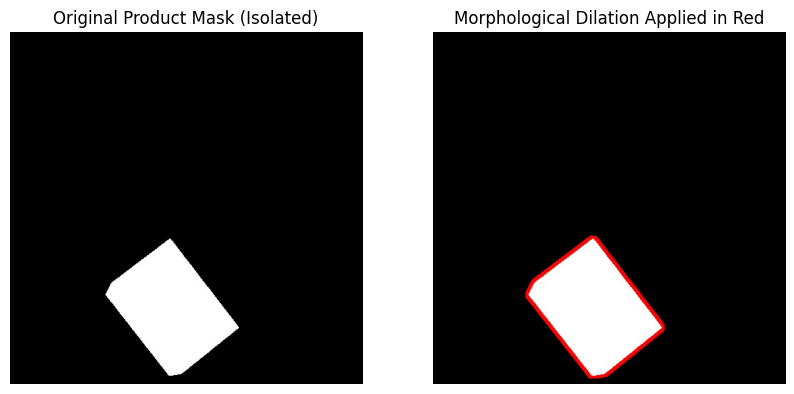

In [4]:
moat1 = cv2.imread("printout/moat/image1.jpg", cv2.IMREAD_GRAYSCALE)

moat2 = cv2.imread("printout/moat/image2.jpg", cv2.COLOR_BGR2GRAY)
moat2 = cv2.cvtColor(moat2, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(1, 2, figsize=(10,5))
axs[0].set_title("Original Product Mask (Isolated)", fontsize=12)
axs[0].imshow(moat1, cmap="gray")
axs[1].set_title("Morphological Dilation Applied in Red", fontsize=12)
axs[1].imshow(moat2)
for ax in axs:
    ax.axis("off")
plt.show()

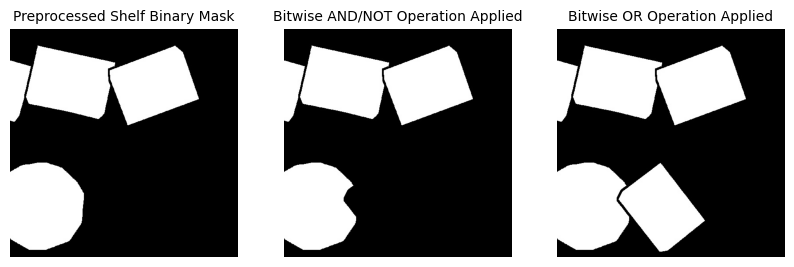

In [5]:
original_bitwise = cv2.imread("printout/moat/image3.jpg", cv2.IMREAD_GRAYSCALE)
cutout_bitwise = cv2.imread("printout/moat/image4.jpg", cv2.IMREAD_GRAYSCALE)
paste_bitwise = cv2.imread("printout/moat/image5.jpg", cv2.IMREAD_GRAYSCALE)

fig, axs = plt.subplots(1, 3, figsize=(10,5))
axs[0].set_title("Preprocessed Shelf Binary Mask", fontsize=10)
axs[0].imshow(original_bitwise, cmap="gray")

axs[1].set_title("Bitwise AND/NOT Operation Applied", fontsize=10)
axs[1].imshow(cutout_bitwise, cmap="gray")

axs[2].set_title("Bitwise OR Operation Applied", fontsize=10)
axs[2].imshow(paste_bitwise, cmap="gray")
for ax in axs:
    ax.axis("off")
plt.show()

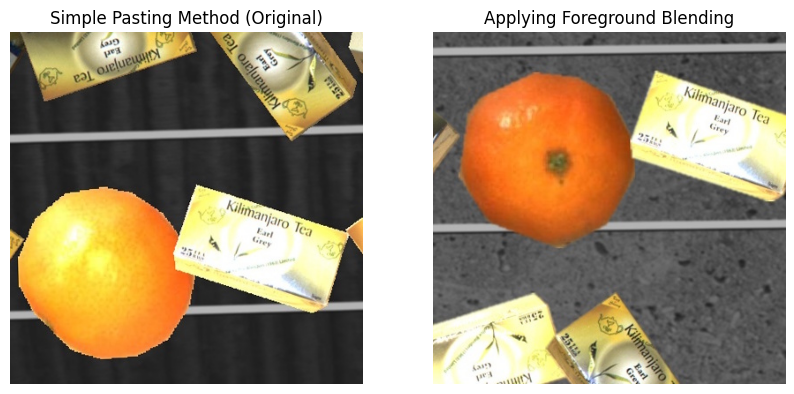

In [6]:
before_blur = cv2.imread("printout/blur_effect/before_blur.jpg", cv2.COLOR_BGR2GRAY)
before_blur = cv2.cvtColor(before_blur, cv2.COLOR_BGR2RGB)

after_blur = cv2.imread("printout/blur_effect/after_blur.jpg", cv2.COLOR_BGR2GRAY)
after_blur = cv2.cvtColor(after_blur, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(1, 2, figsize=(10,5))
axs[0].set_title("Simple Pasting Method (Original)", fontsize=12)
axs[0].imshow(before_blur)
axs[1].set_title("Applying Foreground Blending", fontsize=12)
axs[1].imshow(after_blur)
for ax in axs:
    ax.axis("off")

plt.show()

In [7]:
import numpy as np
import cv2
from scipy.ndimage import distance_transform_edt, label

def heatmap_transform(CURRENT_IMAGE, CURRENT_MASK):
    binary_mask = cv2.imread(CURRENT_MASK, 0)
    binary_mask = (binary_mask > 127).astype(np.uint8)
    # Load Mask
    kernel = np.ones((3, 3), np.uint8)
    mask_for_labeling = cv2.erode(binary_mask, kernel, iterations=2)
    instance_map, num_features = label(mask_for_labeling)

    #Generate Distance Transform
    distance_map = np.zeros_like(instance_map, dtype=np.float32)
    for i in range(1, num_features + 1):
        obj_mask = (instance_map == i)
        # Euclidean Distance Transform computes distance to zero regions
        dist = distance_transform_edt(obj_mask)
        obj_max = dist.max()
        dt_norm = dist / obj_max
        distance_map += (dt_norm * 15)

    # Smooth
    distance_map = cv2.GaussianBlur(distance_map, (15, 15), 0)
    distance_map = distance_map * (instance_map > 0)

    # --Directional Vector--
    # Calculate the numerical gradient (derivative) of an N-dimensional array
    dy, dx = np.gradient(distance_map)

    # Normalize to create unit vectors + epsilon
    magnitude = np.sqrt(dx ** 2 + dy ** 2) + 1e-8
    magnitude[magnitude == 0] = 1 # Avoid division by zero

    u_x = dx / magnitude
    u_y = dy / magnitude

    # Mask out background
    u_x[binary_mask == 0] = 0
    u_y[binary_mask == 0] = 0

    # --Generate Discretized Energy Map--
    direction_target = np.stack([u_x, u_y], axis=0)
    # Energy Labels
    quantized_e = np.floor(distance_map).astype(np.int64)
    quantized_e = np.clip(quantized_e, 0, 15)
    quantized_e[binary_mask == 0] = 0
    energy_target = quantized_e
    return direction_target, energy_target

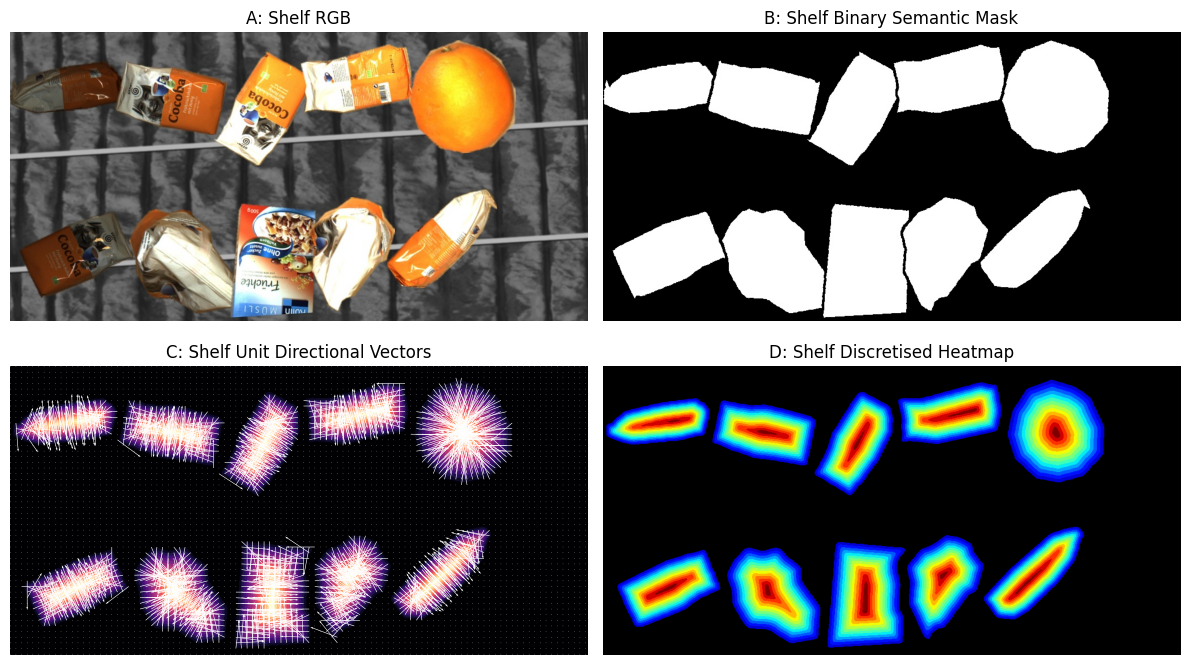

In [8]:
from pathlib import Path
import matplotlib as mpl

cocoba_rgb = cv2.imread("printout/overview/cocoba_rgb.jpg", cv2.COLOR_BGR2RGB)
cocoba_mask = cv2.imread("printout/overview/cocoba_mask.jpg", cv2.IMREAD_GRAYSCALE)
cocoba_rgb_dir = Path("printout/overview/cocoba_rgb.jpg")
cocoba_mask_dir = Path("printout/overview/cocoba_mask.jpg")

cocoba_rgb = cv2.cvtColor(cocoba_rgb, cv2.COLOR_BGR2RGB)

direction, energy = heatmap_transform(cocoba_rgb_dir, cocoba_mask_dir)

fig, axs = plt.subplots(2, 2, figsize=(12,7), gridspec_kw={'width_ratios':[2,2]})

axs[0, 0].set_title("A: Shelf RGB", fontsize=12)
axs[0, 0].imshow(cocoba_rgb)
axs[0, 1].imshow(cocoba_mask, cmap='gray')
axs[0, 1].set_title("B: Shelf Binary Semantic Mask", fontsize=12)

u_x = direction[0]
u_y = direction[1]

h,w = energy.shape
x,y = np.meshgrid(np.arange(w), np.arange(h))
step = 10
sub_x = x[::step, ::step]
sub_y = y[::step, ::step]
sub_u = u_x[::step, ::step]
sub_v = u_y[::step, ::step]

axs[1, 0].set_title("C: Shelf Unit Directional Vectors", fontsize=12)
axs[1, 0].imshow(energy, cmap="magma")
axs[1, 0].quiver(sub_x, sub_y, sub_u, -sub_v, color='white', scale=20, width=0.001)
axs[1, 1].set_title("D: Shelf Discretised Heatmap", fontsize=12)
energy_cmap = mpl.colormaps['jet'].copy()
energy_cmap.set_under('black')
axs[1, 1].imshow(energy, cmap=energy_cmap, vmin=1e-10)
for ax in axs.flat:
    ax.axis("off")

fig.tight_layout()
plt.show()

C:\Users\Thomas Work\AppData\Local\Temp\ipykernel_24412\2386495243.py:36: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
D:\Users\ThomasWork\envs\torch_gpu\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65023 (\N{ARABIC LIGATURE AZZA WA JALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


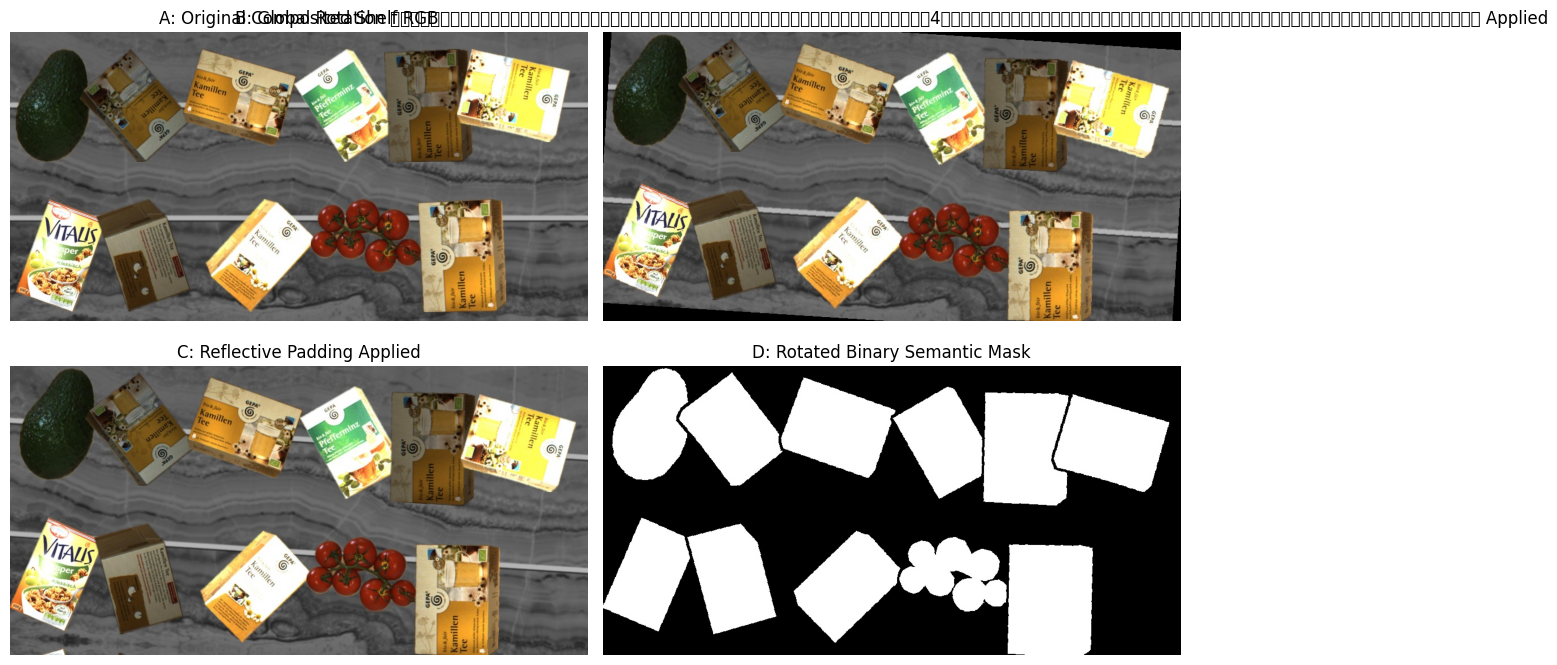

In [9]:
kamillen_rgb = cv2.imread("printout/rotation/rgb_image.jpg", cv2.COLOR_BGR2RGB)
kamillen_rgb = cv2.cvtColor(kamillen_rgb, cv2.COLOR_BGR2RGB)
kamillen_rotation_old_rgb = cv2.imread("printout/rotation/rgb_rotated_old_image.jpg", cv2.COLOR_BGR2RGB)
kamillen_rotation_old_rgb = cv2.cvtColor(kamillen_rotation_old_rgb, cv2.COLOR_BGR2RGB)

kamillen_rotated_rgb = cv2.imread("printout/rotation/rgb_rotated_image.jpg", cv2.COLOR_BGR2RGB)
kamillen_rotated_rgb = cv2.cvtColor(kamillen_rotated_rgb, cv2.COLOR_BGR2RGB)
kamillen_rotated_mask = cv2.imread("printout/rotation/mask_rotated_image.jpg", cv2.IMREAD_GRAYSCALE)

cocoba_rgb = cv2.cvtColor(cocoba_rgb, cv2.COLOR_BGR2RGB)

direction, energy = heatmap_transform(cocoba_rgb_dir, cocoba_mask_dir)
fig, axs = plt.subplots(2, 2, figsize=(12,7), gridspec_kw={'width_ratios':[2,2]})

axs[0, 0].set_title("A: Original Composited Shelf RGB", fontsize=12)
axs[0, 0].imshow(kamillen_rgb)
axs[0, 1].set_title("B: Global Rotation Applied", fontsize=12)
axs[0, 1].imshow(kamillen_rotation_old_rgb)

axs[1, 0].set_title("C: Reflective Padding Applied", fontsize=12)
axs[1, 0].imshow(kamillen_rotated_rgb)
axs[1, 1].set_title("D: Rotated Binary Semantic Mask", fontsize=12)
axs[1, 1].imshow(kamillen_rotated_mask, cmap='gray')
for ax in axs.flat:
    ax.axis("off")

fig.tight_layout()
plt.show()

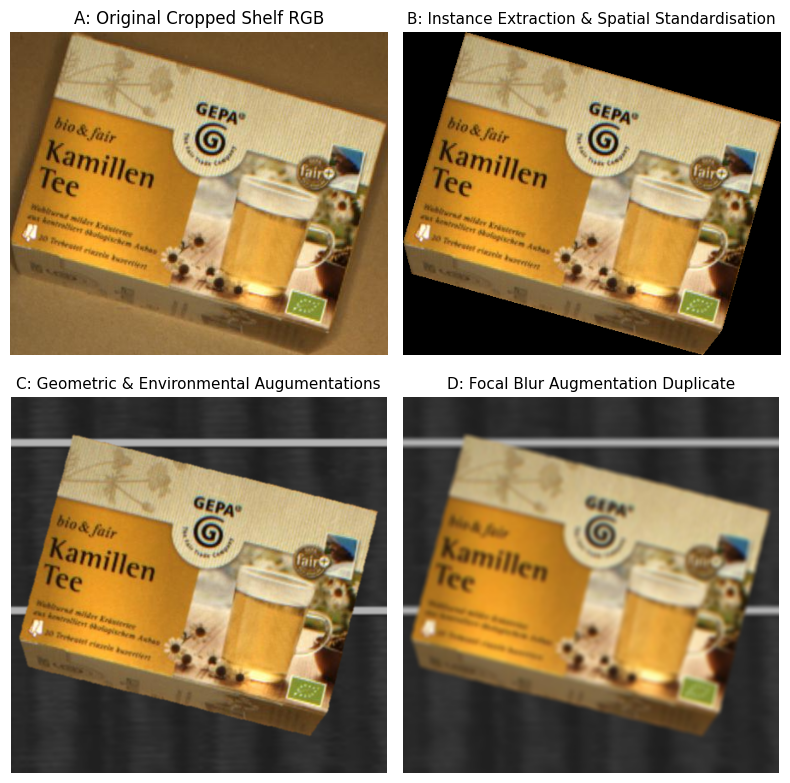

In [10]:
img1 = cv2.imread("printout/single_product_intro/img1.png", cv2.COLOR_BGR2RGB)
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

img2 = cv2.imread("printout/single_product_intro/img2.png", cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

img3 = cv2.imread("printout/single_product_intro/img3.png", cv2.COLOR_BGR2RGB)
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)

img4 = cv2.imread("printout/single_product_intro/img4.png", cv2.COLOR_BGR2RGB)
img4 = cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(2, 2, figsize=(8,8), gridspec_kw={'width_ratios':[2,2]})

axs[0, 0].set_title("A: Original Cropped Shelf RGB", fontsize=12)
axs[0, 0].imshow(img1)
axs[0, 1].set_title("B: Instance Extraction & Spatial Standardisation", fontsize=11)
axs[0, 1].imshow(img2)


axs[1, 0].set_title("C: Geometric & Environmental Augumentations", fontsize=11)
axs[1, 0].imshow(img3)
axs[1, 1].set_title("D: Focal Blur Augmentation Duplicate", fontsize=11)
axs[1, 1].imshow(img4, cmap='gray')
for ax in axs.flat:
    ax.axis("off")

fig.tight_layout()
plt.show()

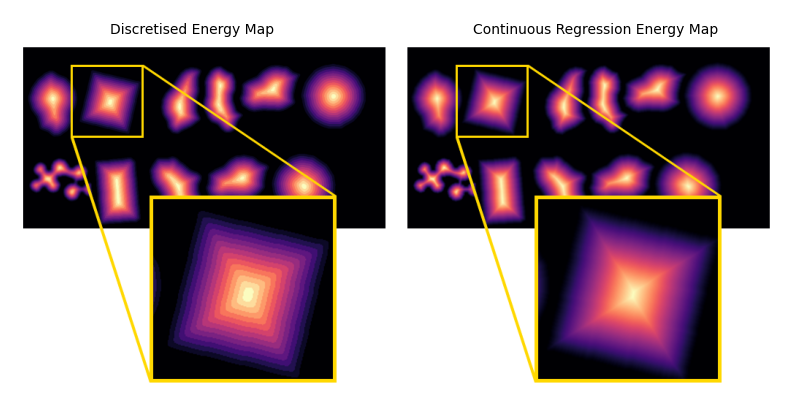

In [11]:
energy = cv2.imread("printout/energy_map/energy_map_comparison.png", cv2.COLOR_BGR2GRAY)
energy = cv2.cvtColor(energy, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(10, 5))

ax.text(0.13, 0.93, "Discretised Energy Map", transform=ax.transAxes,
        fontsize=10, va='bottom', ha='left')

ax.text(0.92, 0.93, "Continuous Regression Energy Map", transform=ax.transAxes,
        fontsize=10, va='bottom', ha='right')

ax.imshow(energy, cmap='gray')
ax.axis("off")

plt.show()

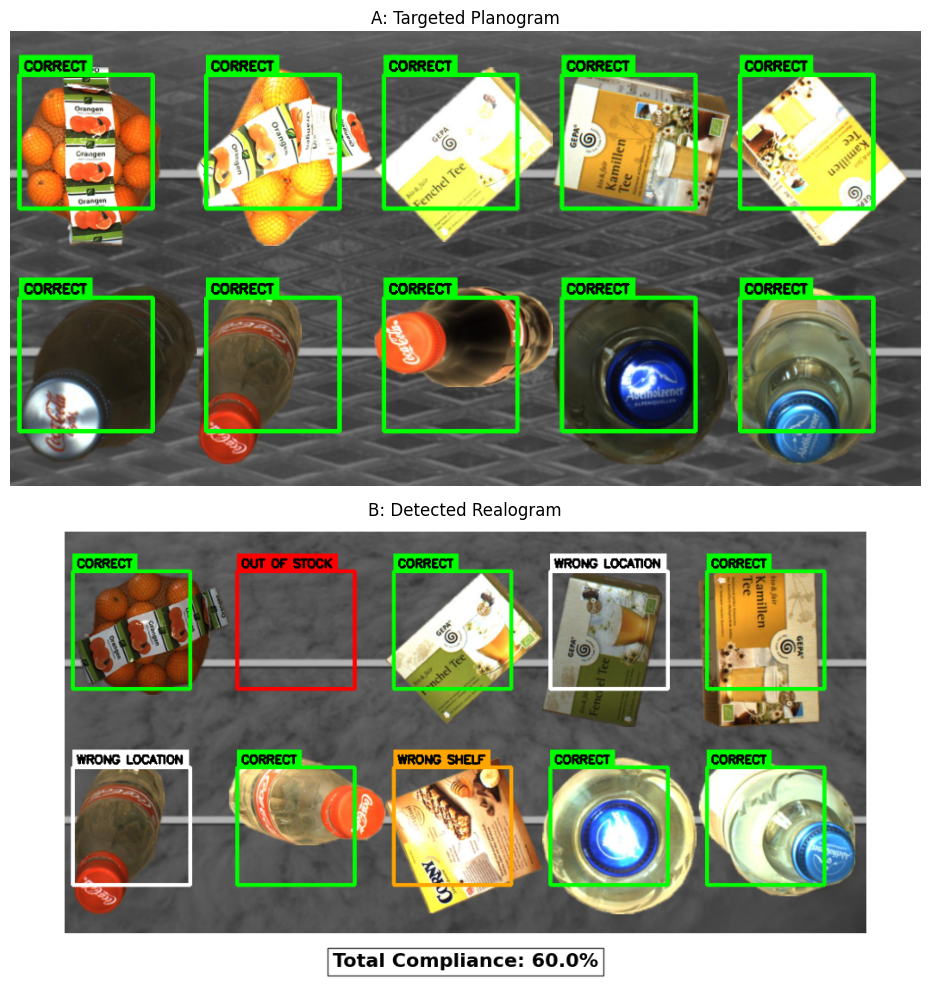

In [12]:
planogram_inference = cv2.imread("printout/planogam_inference/planogram_inference.png", cv2.COLOR_BGR2RGB)
planogram_inference = cv2.cvtColor(planogram_inference, cv2.COLOR_BGR2RGB)

realogram_inference = cv2.imread("printout/planogam_inference/planogram_inference2.png", cv2.COLOR_BGR2RGB)
realogram_inference = cv2.cvtColor(realogram_inference, cv2.COLOR_BGR2RGB)

fig, axs = plt.subplots(2, 1, figsize=(12, 10))


axs[0].set_title("A: Targeted Planogram", fontsize=12)
axs[0].imshow(planogram_inference)


axs[1].set_title("B: Detected Realogram", fontsize=12)
axs[1].imshow(realogram_inference)

for ax in axs:
    ax.axis("off")

fig.tight_layout()

plt.savefig("comparison_output.png", bbox_inches='tight', dpi=300)
plt.show()